# **DATA IMPORTATION**
## Loading libraries

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
data=pd.read_csv("GSSsubset.csv")
data.head()

,id,sex,degree,income,marital,age,height,weight,hrswrk
0,1,MALE,BACHELOR,60967.50,DIVORCED,53,72,190,60
1,2,FEMALE,BACHELOR,60967.50,MARRIED,26,60,97,40
2,4,FEMALE,BACHELOR,10161.25,MARRIED,56,68,160,20
3,14,FEMALE,HIGH SCHOOL,17551.25,MARRIED,40,65,156,37
4,16,MALE,HIGH SCHOOL,17551.25,MARRIED,56,66,210,6


In [28]:
# to display the first 5 rows of the dataset
# data.head()

## Examination of Datasets

In [29]:
data.tail(10)

,id,sex,degree,income,marital,age,height,weight,hrswrk
984,2523,MALE,BACHELOR,24017.50,MARRIED,54,72,195,40
985,2524,MALE,BACHELOR,33255.00,MARRIED,49,70,195,40
986,2525,FEMALE,BACHELOR,33255.00,MARRIED,53,64,150,40
987,2526,MALE,BACHELOR,40645.00,MARRIED,52,72,200,50
988,2530,MALE,HIGH SCHOOL,33255.00,MARRIED,62,71,215,48
989,2531,MALE,HIGH SCHOOL,1478.00,NEVER MARRIED,40,71,230,48
990,2535,MALE,HIGH SCHOOL,33255.00,DIVORCED,56,72,195,46
991,2536,MALE,HIGH SCHOOL,8313.75,NEVER MARRIED,24,68,145,40
992,2537,MALE,HIGH SCHOOL,27712.50,NEVER MARRIED,27,68,180,40
993,2538,FEMALE,HIGH SCHOOL,15703.75,WIDOWED,71,63,140,48


In [30]:
data.info

<bound method DataFrame.info of        id     sex       degree    income        marital  age  height  weight  \
0       1    MALE     BACHELOR  60967.50       DIVORCED   53      72     190   
1       2  FEMALE     BACHELOR  60967.50        MARRIED   26      60      97   
2       4  FEMALE     BACHELOR  10161.25        MARRIED   56      68     160   
3      14  FEMALE  HIGH SCHOOL  17551.25        MARRIED   40      65     156   
4      16    MALE  HIGH SCHOOL  17551.25        MARRIED   56      66     210   
..    ...     ...          ...       ...            ...  ...     ...     ...   
989  2531    MALE  HIGH SCHOOL   1478.00  NEVER MARRIED   40      71     230   
990  2535    MALE  HIGH SCHOOL  33255.00       DIVORCED   56      72     195   
991  2536    MALE  HIGH SCHOOL   8313.75  NEVER MARRIED   24      68     145   
992  2537    MALE  HIGH SCHOOL  27712.50  NEVER MARRIED   27      68     180   
993  2538  FEMALE  HIGH SCHOOL  15703.75        WIDOWED   71      63     140   

     hr

## Data cleaning and preprocessing
### handling missing values
### check for missing values in every column

In [31]:
missing_values=data.isnull().sum()
missing_values

id         0
sex        0
degree     0
income     0
marital    0
age        0
height     0
weight     0
hrswrk     0
dtype: int64

## remove rows with missing values

In [32]:
data.dropna(inplace=True)
missing_values=data.isnull().sum()
missing_values

id         0
sex        0
degree     0
income     0
marital    0
age        0
height     0
weight     0
hrswrk     0
dtype: int64

## identification of outliers using Boxplots (the extreem values)

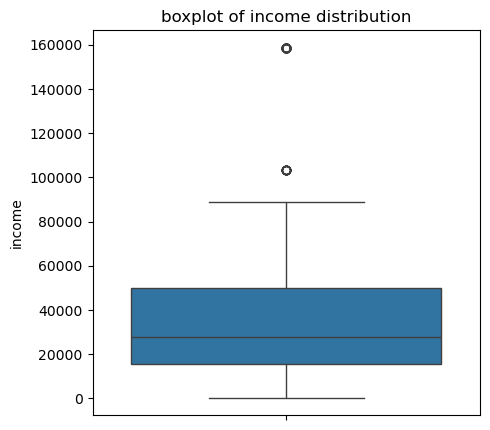

In [33]:
plt.figure(figsize=(5,5))
sns.boxplot(data=data,y="income")
plt.title('boxplot of income distribution')
plt.ylabel("income")
plt.show()

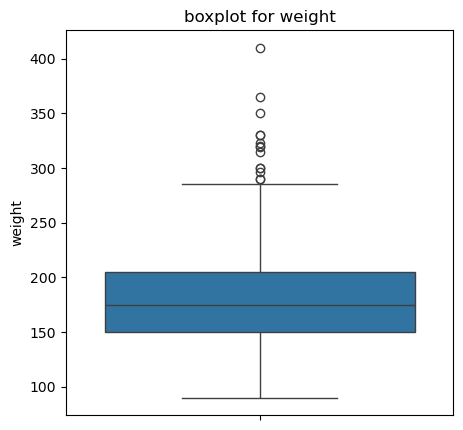

In [34]:
plt.figure(figsize=(5,5))
sns.boxplot(data=data,y="weight")
plt.title('boxplot for weight')
plt.ylabel("weight")
plt.show()

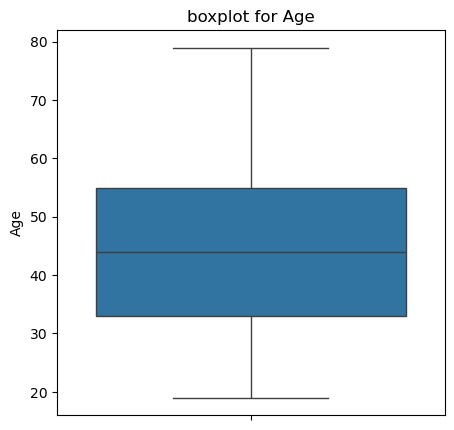

In [35]:
plt.figure(figsize=(5,5))
sns.boxplot(data=data,y="age")
plt.title('boxplot for Age')
plt.ylabel("Age")
plt.show()

## box plot for all numerical variables

AttributeError: module 'matplotlib.pyplot' has no attribute 'tittle'

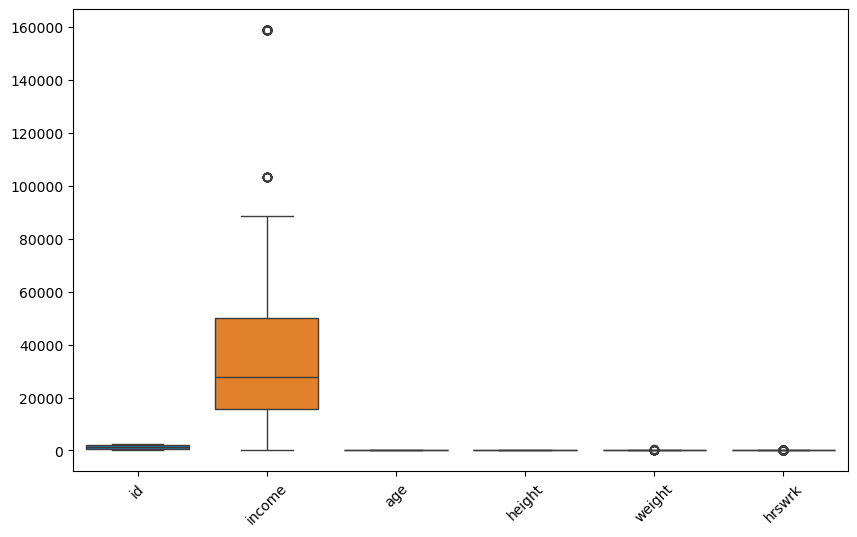

In [36]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data)
# customize plot
plt.xticks(rotation=45) #ROtate x axis lables if needed
plt.tittle("Box plot for all numerical variables")
plt.show()

# Removing outliers
## 1. 1.5 inter-Quartile rule

In [ ]:
# culculating interquatile range
Q1 = data['income'].quantile(0.25)
Q3 = data['income'].quantile(0.75)
IQR = Q3 - Q1
# DEFINE LOWER AND UPPER BOUNDS
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# REMOVING OUTLIERS
data1 = data[(data['income']>=lower_bound)& (data['income']<= upper_bound)]
data


In [1]:
# culculating interquatile range
Q1 = data['income'].quantile(0.25)
Q3 = data['income'].quantile(0.75)
IQR = Q3 - Q1
# DEFINE LOWER AND UPPER BOUNDS
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# REMOVING OUTLIERS
data1 = data[(data['income']>=lower_bound)& (data['income']<= upper_bound)]
data


NameError: name 'data' is not defined

## summary statistics

In [2]:
summary_statistics=data.describe()
summary_statistics

NameError: name 'data' is not defined

In [ ]:
summary_statistics=data.drop(columns=['id']).describe()
summary_statistics

## summary stastistics for categorical variables

In [37]:
categorical_summary=data.describe(include=['O'])
categorical_summary

,sex,degree,marital
count,994,994,994
unique,2,5,5
top,MALE,HIGH SCHOOL,MARRIED
freq,507,491,480


# **Datavisualization**

# histogram

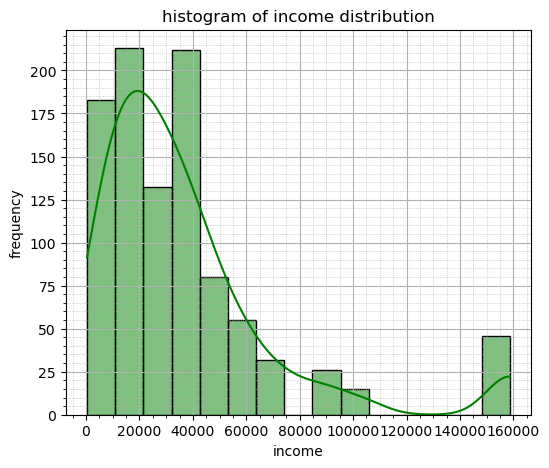

In [42]:
plt.figure(figsize=(6,5))
sns.histplot(data=data, x='income',bins=15,kde=True,color='green')
plt.xlabel('income')
plt.ylabel('frequency')
plt.title('histogram of income distribution')
# plt.minorticks_om
plt.minorticks_on() # enable minor ticks
plt.grid(which='minor', linestyle=':', linewidth=0.5)
plt.grid(True)
plt.show()

## Box plot of income across degree

<function matplotlib.pyplot.show(close=None, block=None)>

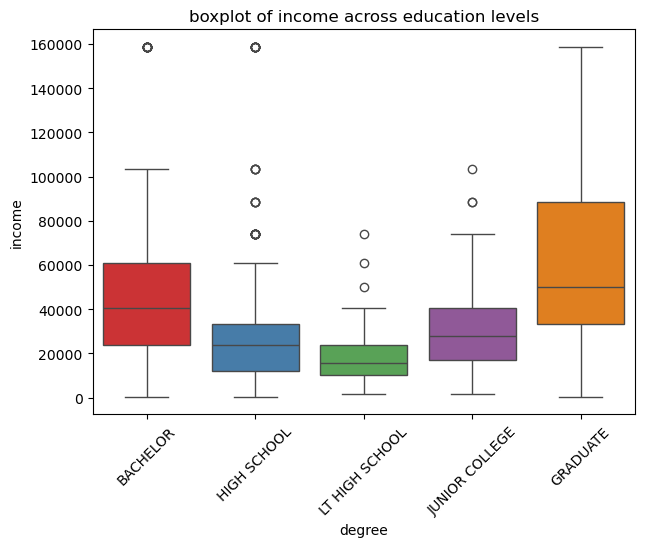

In [47]:
plt.figure(figsize=(7,5))
sns.boxplot(data=data,x='degree',y='income',hue='degree',palette='Set1')
plt.xticks(rotation=45)
plt.xlabel('degree')
plt.ylabel('income')
plt.title('boxplot of income across education levels')
plt.show